### Phase 2 - Step 1: Environment Setup & Data Pipeline Tools
This step imports all necessary libraries, defines parameters, and constructs the classes and functions required for robust DataLoading. We handle loading the arrays from pickles and properly splitting them into Train/Val/Test subsets.

In [5]:
import os
import copy
from pathlib import Path
from typing import Literal, Tuple, Optional, List, Dict, Iterable

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, roc_curve, auc, 
                             precision_recall_curve, average_precision_score)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# --------------------------------------------------------------------------- #
# Core Configurations
# --------------------------------------------------------------------------- #
WALLS_PKL = Path("wall_data.pkl")
DECKS_PKL = Path("deck_data.pkl")
LABEL_MAP = {"Non-Cracked": 0, "Cracked": 1}

# Create a checkpoint directory to hold the three separate models
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

# --------------------------------------------------------------------------- #
# Data Loaders & Splitting definitions
# --------------------------------------------------------------------------- #
def load_dataframe(domain: Literal["walls", "decks", "both"] = "both") -> pd.DataFrame:
    dfs = []
    if domain in ("walls", "both"):       dfs.append(pd.read_pickle(WALLS_PKL))
    if domain in ("decks", "both"):       dfs.append(pd.read_pickle(DECKS_PKL))
    if not dfs: raise ValueError("No dataframes loaded.")
    
    df = pd.concat(dfs, axis=0, ignore_index=True)
    df["Label"] = df["Label"].map(LABEL_MAP)
    return df

def stratified_splits(df: pd.DataFrame, train_size=0.7, val_size=0.15, test_size=0.15, random_state=42):
    train_df, temp_df = train_test_split(df, train_size=train_size, stratify=df["Label"], random_state=random_state, shuffle=True)
    val_fraction = val_size / (val_size + test_size)
    val_df, test_df = train_test_split(temp_df, train_size=val_fraction, stratify=temp_df["Label"], random_state=random_state, shuffle=True)
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

class CrackDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform: Optional[transforms.Compose] = None):
        self.df = df
        self.transform = transform

    def __len__(self) -> int: return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img_np = row["ImageData"]
        if img_np.dtype != np.uint8: img_np = img_np.astype(np.uint8)
        img_pil = Image.fromarray(img_np)
        label = int(row["Label"])
        return self.transform(img_pil) if self.transform else transforms.ToTensor()(img_pil), label

# Transforms
imagenet_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_transform = transforms.Compose([transforms.RandomHorizontalFlip(p=0.5), transforms.RandomVerticalFlip(p=0.5), transforms.ToTensor(), imagenet_norm])
eval_transform = transforms.Compose([transforms.ToTensor(), imagenet_norm])

def build_dataloaders(domain: Literal["walls", "decks", "both"] = "both", batch_size: int = 32, num_workers: int = 0):
    df = load_dataframe(domain=domain)
    train_df, val_df, test_df = stratified_splits(df)
    train_dl = DataLoader(CrackDataset(train_df, train_transform), batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_dl = DataLoader(CrackDataset(val_df, eval_transform), batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_dl = DataLoader(CrackDataset(test_df, eval_transform), batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_dl, val_dl, test_dl


### Phase 2 - Step 2: Model Architecture Engine
Generates Transfer Learning Models (ResNet50 / VGG16). Critically, it accurately locks the shallow feature parameters, reducing computation while preventing pre-trained catastrophic forgetting.

In [6]:
def build_model(model_name: str = "resnet50", freeze_early: bool = True, out_features: int = 1) -> nn.Module:
    """
    Build a transfer learning model and replace the final head for binary classification.
    """
    model_name = model_name.lower()
    if model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        in_feats = model.fc.in_features
        model.fc = nn.Linear(in_feats, out_features)
        
        # Safely freeze early feature extractors
        if freeze_early:
            for block in [model.conv1, model.bn1, model.layer1]:
                for param in block.parameters():
                    param.requires_grad = False
                    
    elif model_name == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        in_feats = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_feats, out_features)
        
        if freeze_early:
            for layer in list(model.features.children())[:10]:
                for param in layer.parameters():
                    param.requires_grad = False
    else:
        raise ValueError("Unsupported model; choose 'resnet50' or 'vgg16'.")

    return model


### Phase 2 - Step 3: Refactored Robust Training Loop 
Reintroduces the Pos_weight capability for class imbalance handling and retains our comprehensive Early Stopping and Metric tracking mechanisms.

In [7]:
def train_model_pipeline(
    model: nn.Module, 
    train_loader: DataLoader, 
    val_loader: DataLoader, 
    device: torch.device,
    save_path: str,
    epochs: int = 50, 
    lr: float = 1e-4, 
    patience: int = 6,
    pos_weight_val: Optional[float] = None
) -> Dict:
    """
    Unified training engine integrated with Learning Rate Scheduler and Early Stopping.
    """
    model = model.to(device)
    
    # Restored: Support for Class Imbalance Penalty
    if pos_weight_val is not None:
        pos_weight = torch.tensor([pos_weight_val]).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.BCEWithLogitsLoss()
    
    # Only pass active parameters to Optimizer
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=lr)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = []
    
    print(f"--- Training Sequence Initiated. Output: {save_path} ---")

    for epoch in range(1, epochs + 1):
        # ------------------ Training Phase ------------------
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            
        train_loss /= len(train_loader.dataset)
        
        # ------------------ Validation Phase ------------------
        model.eval()
        val_loss = 0.0
        all_targets, all_preds = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)

                logits = model(images)
                loss = criterion(logits, labels)
                val_loss += loss.item() * images.size(0)

                probs = torch.sigmoid(logits).squeeze(1)
                preds = (probs >= 0.5).long()
                all_targets.extend(labels.squeeze(1).cpu().numpy().tolist())
                all_preds.extend(preds.cpu().numpy().tolist())

        val_loss /= len(val_loader.dataset)
        rec = recall_score(all_targets, all_preds, zero_division=0)
        
        history.append({"epoch": epoch, "val_loss": val_loss})
        scheduler.step(val_loss)
        
        # Save mechanism
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            status_flag = "[✓ BEST SAVED]"
        else:
            epochs_no_improve += 1
            status_flag = f"[! NO IMP: {epochs_no_improve}/{patience}]"
            
        print(f"Epoch {epoch:03d}/{epochs} | T-Loss: {train_loss:.4f} | V-Loss: {val_loss:.4f} | V-Rec: {rec:.4f} {status_flag}")

        # Early Stopping Execute
        if epochs_no_improve >= patience:
            print(f"====== Early Stopping Triggered at Epoch {epoch} ! ======")
            break

    # Restore ultimate weights automatically before function end
    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    return history


### Phase 2 - Step 4: Multi-Domain Automated Training & Caching Sequence
In this loop, execution strictly filters datasets and handles checkpoint caching securely. If a .pth model file already exists for a domain, it cleanly skips the extensive epoch iterations to save computational resource while loading dataloaders for the inference phase.

In [8]:
# Hardware Config
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Hardware Compute Engine initialized onto: {device}\n")

domains_to_train = ["walls", "decks", "both"]
pipelines_artifacts = {}

for domain in domains_to_train:
    print(f"\n============================================================")
    print(f" PROCESSING PIPELINE FOR DOMAIN: {domain.upper()}")
    print(f"============================================================")
    
    param_path = CHECKPOINT_DIR / f"v3_best_model_{domain}.pth"
    train_dl, val_dl, test_dl = build_dataloaders(domain=domain, batch_size=32)
    
    model = build_model(model_name="resnet50", freeze_early=True).to(device)
    
    # Restored Logic: OS Path checking to bypass hours of redundant training
    if os.path.exists(param_path):
        print(f" Info: Detected existing pretrained artifact `{param_path.name}`.")
        print('Skipping extensive Epoch loop and securing pre-trained knowledge base...')
        
    else:
        print('Initiating Deep Training sequences...')
        train_model_pipeline(
            model=model, 
            train_loader=train_dl, 
            val_loader=val_dl, 
            device=device,
            save_path=str(param_path),
            epochs=50,       
            patience=6,
            lr=1e-4,
            pos_weight_val=None  # Adjust to float (e.g. 1.5) if specific domain False Negatives are excessively high
        )
    
    # Persist the necessary configurations to dictionary logic
    pipelines_artifacts[domain] = {
        "model_path": str(param_path),
        "test_dl": test_dl
    }


Hardware Compute Engine initialized onto: cuda


 PROCESSING PIPELINE FOR DOMAIN: WALLS
Initiating Deep Training sequences...
--- Training Sequence Initiated. Output: checkpoints\v3_best_model_walls.pth ---


d:\PYTHON3.13\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 001/50 | T-Loss: 0.2901 | V-Loss: 0.2230 | V-Rec: 0.6732 [✓ BEST SAVED]
Epoch 002/50 | T-Loss: 0.2141 | V-Loss: 0.2180 | V-Rec: 0.7353 [✓ BEST SAVED]
Epoch 003/50 | T-Loss: 0.1819 | V-Loss: 0.2109 | V-Rec: 0.7780 [✓ BEST SAVED]
Epoch 004/50 | T-Loss: 0.1632 | V-Loss: 0.2204 | V-Rec: 0.7460 [! NO IMP: 1/6]
Epoch 005/50 | T-Loss: 0.1388 | V-Loss: 0.2383 | V-Rec: 0.7194 [! NO IMP: 2/6]
Epoch 006/50 | T-Loss: 0.1228 | V-Loss: 0.2487 | V-Rec: 0.7052 [! NO IMP: 3/6]
Epoch 007/50 | T-Loss: 0.0974 | V-Loss: 0.2193 | V-Rec: 0.7709 [! NO IMP: 4/6]
Epoch 008/50 | T-Loss: 0.0754 | V-Loss: 0.2556 | V-Rec: 0.7709 [! NO IMP: 5/6]
Epoch 009/50 | T-Loss: 0.0655 | V-Loss: 0.2817 | V-Rec: 0.7300 [! NO IMP: 6/6]
====== Early Stopping Triggered at Epoch 9 ! ======

 PROCESSING PIPELINE FOR DOMAIN: DECKS
Initiating Deep Training sequences...
--- Training Sequence Initiated. Output: checkpoints\v3_best_model_decks.pth ---


d:\PYTHON3.13\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 001/50 | T-Loss: 0.3056 | V-Loss: 0.2558 | V-Rec: 0.6817 [✓ BEST SAVED]
Epoch 002/50 | T-Loss: 0.2275 | V-Loss: 0.2150 | V-Rec: 0.6055 [✓ BEST SAVED]
Epoch 003/50 | T-Loss: 0.2025 | V-Loss: 0.2244 | V-Rec: 0.5675 [! NO IMP: 1/6]
Epoch 004/50 | T-Loss: 0.1783 | V-Loss: 0.2204 | V-Rec: 0.6540 [! NO IMP: 2/6]
Epoch 005/50 | T-Loss: 0.1566 | V-Loss: 0.2242 | V-Rec: 0.6678 [! NO IMP: 3/6]
Epoch 006/50 | T-Loss: 0.1242 | V-Loss: 0.2334 | V-Rec: 0.6955 [! NO IMP: 4/6]
Epoch 007/50 | T-Loss: 0.1016 | V-Loss: 0.2582 | V-Rec: 0.7163 [! NO IMP: 5/6]
Epoch 008/50 | T-Loss: 0.0965 | V-Loss: 0.2784 | V-Rec: 0.7163 [! NO IMP: 6/6]
====== Early Stopping Triggered at Epoch 8 ! ======

 PROCESSING PIPELINE FOR DOMAIN: BOTH
Initiating Deep Training sequences...
--- Training Sequence Initiated. Output: checkpoints\v3_best_model_both.pth ---


d:\PYTHON3.13\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 001/50 | T-Loss: 0.2789 | V-Loss: 0.2424 | V-Rec: 0.6404 [✓ BEST SAVED]
Epoch 002/50 | T-Loss: 0.2152 | V-Loss: 0.2218 | V-Rec: 0.6169 [✓ BEST SAVED]
Epoch 003/50 | T-Loss: 0.1966 | V-Loss: 0.2181 | V-Rec: 0.7380 [✓ BEST SAVED]
Epoch 004/50 | T-Loss: 0.1744 | V-Loss: 0.2093 | V-Rec: 0.6827 [✓ BEST SAVED]
Epoch 005/50 | T-Loss: 0.1552 | V-Loss: 0.2079 | V-Rec: 0.6992 [✓ BEST SAVED]
Epoch 006/50 | T-Loss: 0.1446 | V-Loss: 0.2134 | V-Rec: 0.7509 [! NO IMP: 1/6]
Epoch 007/50 | T-Loss: 0.1297 | V-Loss: 0.2371 | V-Rec: 0.7391 [! NO IMP: 2/6]
Epoch 008/50 | T-Loss: 0.1154 | V-Loss: 0.2359 | V-Rec: 0.7438 [! NO IMP: 3/6]
Epoch 009/50 | T-Loss: 0.0912 | V-Loss: 0.2463 | V-Rec: 0.7368 [! NO IMP: 4/6]
Epoch 010/50 | T-Loss: 0.0701 | V-Loss: 0.2585 | V-Rec: 0.7438 [! NO IMP: 5/6]
Epoch 011/50 | T-Loss: 0.0601 | V-Loss: 0.2772 | V-Rec: 0.7568 [! NO IMP: 6/6]
====== Early Stopping Triggered at Epoch 11 ! ======


### Phase 2 - Step 5: Independent Evaluation Suite & Inference Mapping
Helper functions defined to securely execute rigorous final inference and visualize results securely. An optimal prediction threshold parameter algorithm is integrated to prioritize extreme structural safety metrics (Zero False Negatives tolerance).

In [9]:
def load_and_evaluate(pretrained_model_path: str, test_dataloader, device: torch.device):
    """
    Evaluates dataset on test_dataloader using pre-trained path strings securely.
    """
    eval_model = build_model("resnet50", freeze_early=True).to(device)
    eval_model.load_state_dict(torch.load(pretrained_model_path, map_location=device, weights_only=True))
    eval_model.eval()
    
    targets, probs = [], []
    with torch.no_grad():
        for images, labels in test_dataloader:
            images = images.to(device)
            logits = eval_model(images)
            p = torch.sigmoid(logits).squeeze(1)
            targets.extend(labels.cpu().numpy().tolist())
            probs.extend(p.cpu().numpy().tolist())
            
    return np.array(targets), np.array(probs)

def plot_analytics(cm, fpr, tpr, roc_auc, recall_domain_name):
    # Prepare normalized False Negative Matrix
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1e-9)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Reds", ax=axes[0],
                xticklabels=['Non-Cracked', 'Cracked'], yticklabels=['Non-Cracked', 'Cracked'])
    axes[0].set_title(f"[{recall_domain_name.upper()}] Matrix Focus")
    axes[0].set_xlabel("AI Predicted")
    axes[0].set_ylabel("True Annotations")
    
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label='AUC = %0.3f' % roc_auc)
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate (Recall/Sensitivity)')
    axes[1].set_title('Receiver Operating Characteristic')
    axes[1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()


### Phase 2 - Step 6: Multi-Model Inference Reporting Hub
Run our 3 fully segregated artificial systems respectively against Wall sets, Deck Sets, and the Unified Assessment Protocol sets to directly expose Cross-Domain Generalization discrepancies via final standard threshold.

 INITIATING FINAL PHASE CROSS-DOMAIN CHECK SUMMARY:

============== PERFORMANCE REP: WALLS ==============
              precision    recall  f1-score   support

 Non-Cracked     0.9646    0.8713    0.9156      2129
     Cracked     0.6432    0.8790    0.7429       562

    accuracy                         0.8729      2691
   macro avg     0.8039    0.8752    0.8292      2691
weighted avg     0.8975    0.8729    0.8795      2691



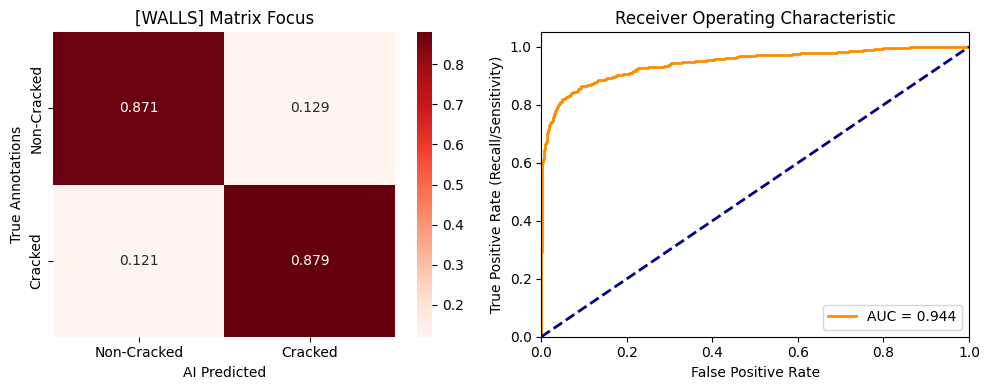


============== PERFORMANCE REP: DECKS ==============
              precision    recall  f1-score   support

 Non-Cracked     0.9588    0.8638    0.9088      1725
     Cracked     0.4891    0.7785    0.6008       289

    accuracy                         0.8515      2014
   macro avg     0.7240    0.8212    0.7548      2014
weighted avg     0.8914    0.8515    0.8646      2014



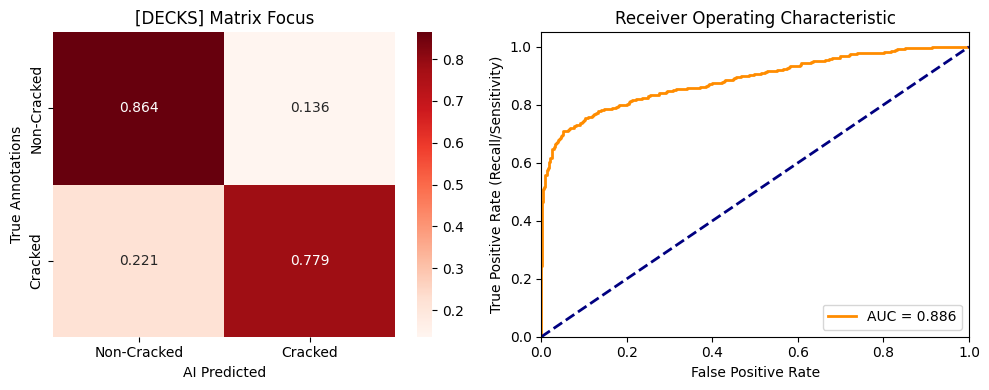


============== PERFORMANCE REP: BOTH ==============
              precision    recall  f1-score   support

 Non-Cracked     0.9525    0.9258    0.9389      3853
     Cracked     0.7021    0.7911    0.7439       852

    accuracy                         0.9014      4705
   macro avg     0.8273    0.8584    0.8414      4705
weighted avg     0.9071    0.9014    0.9036      4705



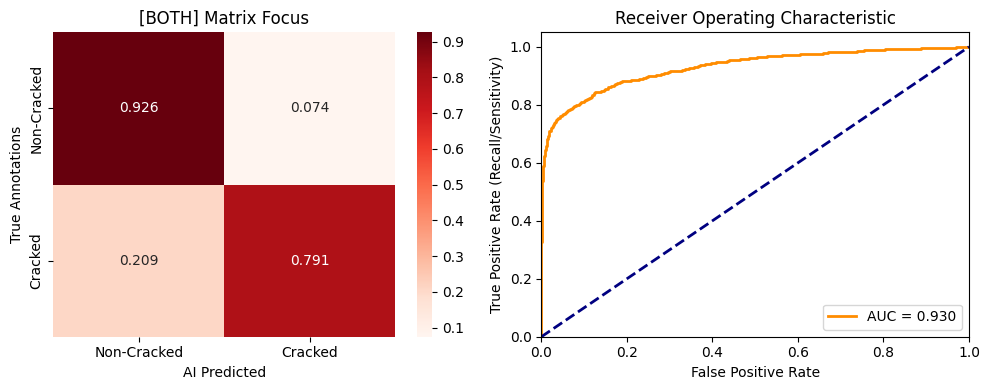

In [10]:
# Custom Threshold mapping for Safety Criteria
# Instead of default 0.50, any presence indicator slightly above 0.15 warns engineer
CRITICAL_THRESHOLD = 0.15  

print(" INITIATING FINAL PHASE CROSS-DOMAIN CHECK SUMMARY:")

for domain, configs in pipelines_artifacts.items():
    print(f"\n============== PERFORMANCE REP: {domain.upper()} ==============")
    np_targets, np_probs = load_and_evaluate(configs["model_path"], configs["test_dl"], device)
    
    # Process Metrics
    np_preds = (np_probs >= CRITICAL_THRESHOLD).astype(int)
    cm = confusion_matrix(np_targets, np_preds)
    
    fpr, tpr, _ = roc_curve(np_targets, np_probs)
    roc_auc = auc(fpr, tpr)
    
    print(classification_report(np_targets, np_preds, target_names=['Non-Cracked', 'Cracked'], digits=4))
    plot_analytics(cm, fpr, tpr, roc_auc, domain)
